# Landmark Layout Planner
Reads `config/settings.yaml` and plots the physical setup.
**Edit the YAML, press Ctrl+S here to save, then re-run the plot cell.**

In [3]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyyaml', 'numpy', 'matplotlib'])

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

CalledProcessError: Command '['/usr/bin/python3', '-m', 'pip', 'install', 'pyyaml', 'numpy', 'matplotlib']' returned non-zero exit status 1.

In [1]:
import numpy as np

RECT_W      = 1.5      # rectangle width  in m (short edge, x direction)
RECT_H      = 2.0      # rectangle height in m (long edge,  y direction)
CUBE_SIZE   = 0.077    # actual printed tag size in m 
TAGS_PER_CUBE = 4

ox = -RECT_W / 2.0   # left edge x offset from robot

cubes = [
    {'id': 1, 'x': ox,           'y': 0.0         },  # bottom-left  corner
    {'id': 2, 'x': ox + RECT_W,  'y': 0.0         },  # bottom-right corner
    {'id': 3, 'x': ox + RECT_W,  'y': RECT_H      },  # top-right    corner
    {'id': 4, 'x': ox,           'y': RECT_H      },  # top-left     corner
    {'id': 5, 'x': ox + RECT_W,  'y': RECT_H / 2.0},  # right long-edge midpoint
    {'id': 6, 'x': ox,           'y': RECT_H / 2.0},  # left  long-edge midpoint
]

# ── Print YAML ────────────────────────────────────────────────────────────────
print('# ── Paste into config/settings.yaml ──────────────────────────────────')
print('landmarks:')
print('  # x, y: cube center in map frame (m).  size: actual printed tag size (m).')
print('  # yaw: orientation (rad), 0 = face 0 points +x. tag_ids: CCW from yaw.')
for c in cubes:
    base_id = (c['id'] - 1) * TAGS_PER_CUBE
    tag_ids = list(range(base_id, base_id + TAGS_PER_CUBE))
    print(f"  - id: {c['id']}")
    print(f"    x: {c['x']:.4f}")
    print(f"    y: {c['y']:.4f}")
    print(f"    size: {CUBE_SIZE}")
    print(f"    yaw: 0.0")
    print(f"    tag_ids: {tag_ids}")

print()
print('# ── Paste into initial_state_mean ────────────────────────────────────')
print('initial_state_mean: [0.0, 0.0, 1.5708]  # robot at map origin, facing +y')
print()
print(f'# ── apriltag_ros launch file ──────────────────────────────────────────')
print(f'tag_family: tag36h11')
print(f'tag_size: {CUBE_SIZE}  # must match printed size exactly')

# ── Paste into config/settings.yaml ──────────────────────────────────
landmarks:
  # x, y: cube center in map frame (m).  size: actual printed tag size (m).
  # yaw: orientation (rad), 0 = face 0 points +x. tag_ids: CCW from yaw.
  - id: 1
    x: -0.7500
    y: 0.0000
    size: 0.077
    yaw: 0.0
    tag_ids: [0, 1, 2, 3]
  - id: 2
    x: 0.7500
    y: 0.0000
    size: 0.077
    yaw: 0.0
    tag_ids: [4, 5, 6, 7]
  - id: 3
    x: 0.7500
    y: 2.0000
    size: 0.077
    yaw: 0.0
    tag_ids: [8, 9, 10, 11]
  - id: 4
    x: -0.7500
    y: 2.0000
    size: 0.077
    yaw: 0.0
    tag_ids: [12, 13, 14, 15]
  - id: 5
    x: 0.7500
    y: 1.0000
    size: 0.077
    yaw: 0.0
    tag_ids: [16, 17, 18, 19]
  - id: 6
    x: -0.7500
    y: 1.0000
    size: 0.077
    yaw: 0.0
    tag_ids: [20, 21, 22, 23]

# ── Paste into initial_state_mean ────────────────────────────────────
initial_state_mean: [0.0, 0.0, 1.5708]  # robot at map origin, facing +y

# ── apriltag_ros launch file ────────────────

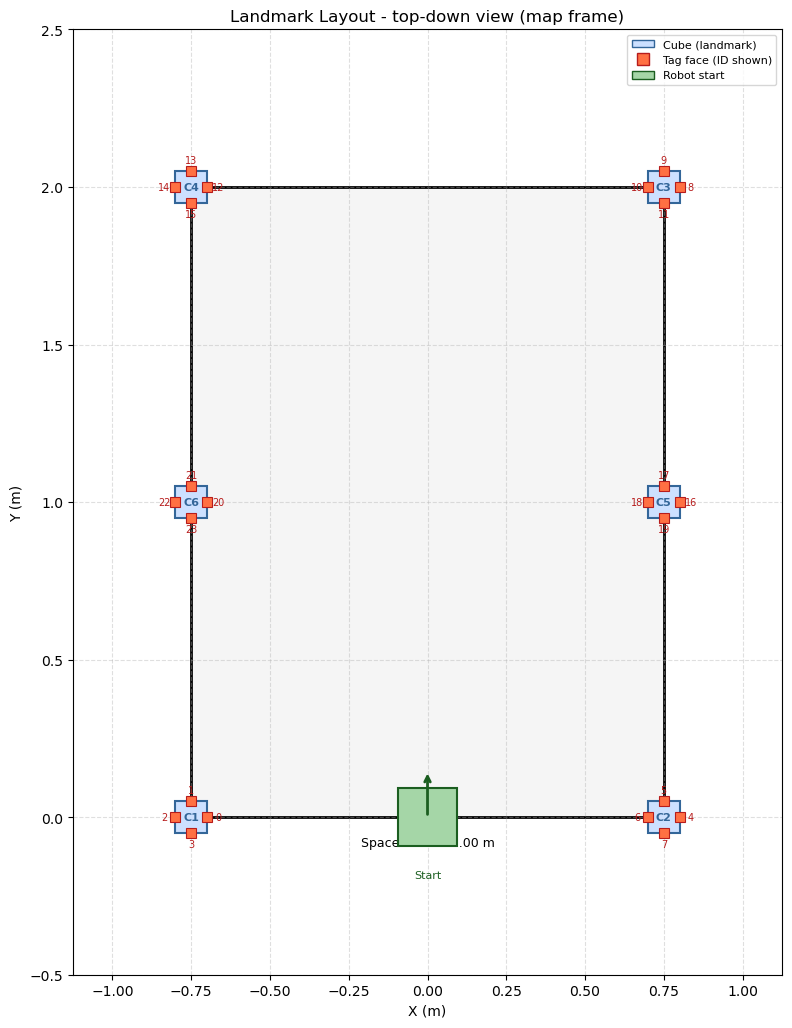

In [ ]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

ROBOT_SIZE = 0.185  # robot footprint side length in m

# Load config
with open('config/settings.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

landmarks   = cfg['landmarks']
robot_start = cfg['initial_state_mean']   # [x, y, theta]

# Derive space envelope from landmark extents
xs = [lm['x'] for lm in landmarks]
ys = [lm['y'] for lm in landmarks]
SPACE_ORIGIN_X = min(xs)
SPACE_ORIGIN_Y = min(ys)
SPACE_W        = max(xs) - min(xs)
SPACE_H        = max(ys) - min(ys)

margin_x = SPACE_W * 0.25
margin_y = SPACE_H * 0.25
view_w = SPACE_W + 2 * margin_x
view_h = SPACE_H + 2 * margin_y
fig, ax = plt.subplots(figsize=(8, 8 * view_h / view_w))

# Space boundary
ax.add_patch(patches.Rectangle(
    (SPACE_ORIGIN_X, SPACE_ORIGIN_Y), SPACE_W, SPACE_H,
    linewidth=2, edgecolor='black', facecolor='#f5f5f5', zorder=0
))
ax.text(SPACE_ORIGIN_X + SPACE_W / 2, SPACE_ORIGIN_Y - SPACE_H * 0.03,
        f'Space  {SPACE_W:.2f} x {SPACE_H:.2f} m',
        ha='center', va='top', fontsize=9, color='black')

# Landmark cubes & face tags
for lm in landmarks:
    cx, cy  = lm['x'], lm['y']
    half    = lm['size'] / 2.0
    yaw     = lm['yaw']
    cube_id = lm['id']

    corners = np.array([[-half, -half], [ half, -half],
                        [ half,  half], [-half,  half]])
    R = np.array([[np.cos(yaw), -np.sin(yaw)],
                  [np.sin(yaw),  np.cos(yaw)]])
    corners = (R @ corners.T).T + np.array([cx, cy])
    ax.add_patch(plt.Polygon(corners, closed=True,
                             facecolor='#cce0ff', edgecolor='#336699',
                             linewidth=1.5, zorder=2))
    ax.text(cx, cy, f'C{cube_id}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='#336699', zorder=5)

    for i, tid in enumerate(lm['tag_ids']):
        angle = yaw + i * (np.pi / 2.0)
        fx = cx + half * np.cos(angle)
        fy = cy + half * np.sin(angle)
        ax.plot(fx, fy, 's', markersize=7, color='#ff7043',
                markeredgecolor='#b71c1c', markeredgewidth=0.8, zorder=4)
        lx = cx + half * 1.7 * np.cos(angle)
        ly = cy + half * 1.7 * np.sin(angle)
        ax.text(lx, ly, f'{tid}', ha='center', va='center',
                fontsize=7, color='#b71c1c', zorder=5)

# Robot start pose
rx, ry, rtheta = robot_start
ax.add_patch(patches.Rectangle(
    (rx - ROBOT_SIZE / 2, ry - ROBOT_SIZE / 2), ROBOT_SIZE, ROBOT_SIZE,
    linewidth=1.5, edgecolor='#1b5e20', facecolor='#a5d6a7', zorder=3
))
ax.annotate('',
    xy=(rx + ROBOT_SIZE * 0.8 * np.cos(rtheta), ry + ROBOT_SIZE * 0.8 * np.sin(rtheta)),
    xytext=(rx, ry),
    arrowprops=dict(arrowstyle='->', color='#1b5e20', lw=2), zorder=6)
ax.text(rx, ry - ROBOT_SIZE * 0.9, 'Start', ha='center', va='top',
        fontsize=8, color='#1b5e20', zorder=5)

# Legend
ax.legend(handles=[
    patches.Patch(facecolor='#cce0ff', edgecolor='#336699', label='Cube (landmark)'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#ff7043',
               markeredgecolor='#b71c1c', markersize=8, label='Tag face (ID shown)'),
    patches.Patch(facecolor='#a5d6a7', edgecolor='#1b5e20', label='Robot start'),
], loc='upper right', fontsize=8)

ax.set_xlim(SPACE_ORIGIN_X - margin_x, SPACE_ORIGIN_X + SPACE_W + margin_x)
ax.set_ylim(SPACE_ORIGIN_Y - margin_y, SPACE_ORIGIN_Y + SPACE_H + margin_y)
ax.set_aspect('equal')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Landmark Layout - top-down view (map frame)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('layout_preview.png', dpi=150)
plt.show()